# Graph embeddings

### Imports

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import os
import pandas as pd
import pydot

from reeb_utils import do_reeb_for_start_end, do_reeb_for_explore_node, plot_treeb

pd.options.mode.chained_assignment = None

### Load data

In [2]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df.head()

,dates,times,X,Subject,eprocs,Task_type,Procedure,Sample,objlist,PairList,...,Press.S.L,Press.S.M.L,fmv_duration,path_dist_trav,euc_dist_trav,path_efficiencies,path_efficiencies_acc_only,subj_mean_acc,path_mean_acc,quartile
2,2017-02-07,15:29:23,3,2,Test_Trials_B_1-002-1,B1,TrialProc,1.0,20.0,8.0,...,S,M,1618.0,31.25,10.854147,2.551020,NaN,0.916667,0.686567,3
3,2017-02-07,15:29:23,4,2,Test_Trials_B_1-002-1,B1,TrialProc,2.0,61.0,7.0,...,S,S,1051.0,23.00,11.450982,1.000000,NaN,0.916667,0.671429,3
4,2017-02-07,15:29:23,5,2,Test_Trials_B_1-002-1,B1,TrialProc,3.0,67.0,1.0,...,L,M,1051.0,22.50,2.263846,1.000000,1.000000,0.916667,0.557143,3
5,2017-02-07,15:29:23,6,2,Test_Trials_B_1-002-1,B1,TrialRevProc,4.0,21.0,2.0,...,L,L,1051.0,31.50,9.013878,1.235294,1.235294,0.916667,0.637681,3
6,2017-02-07,15:29:23,7,2,Test_Trials_B_1-002-1,B1,TrialRevProc,5.0,58.0,3.0,...,L,L,1051.0,23.00,14.705441,1.000000,1.000000,0.916667,0.716418,3


#### Let's make a graph to use!

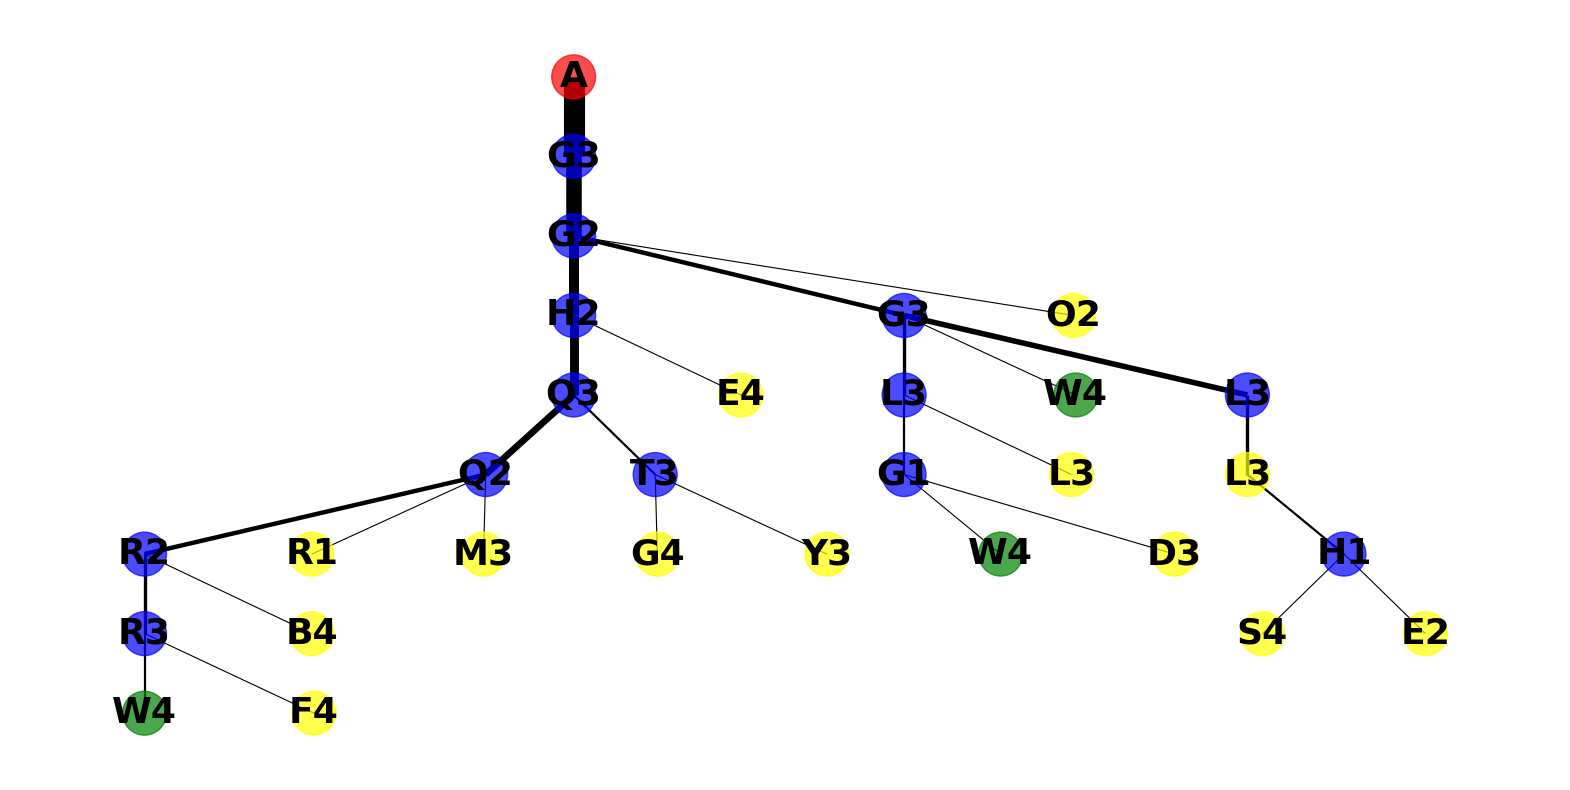

In [3]:
G = do_reeb_for_start_end(test_df, "A", "W", 1, use_turns=True)
plot_treeb(G)

In [5]:
# JK let's make ten of them!
treebs = []
count = 0
for start_node, end_node in test_df.groupby(["StartAt", "EndAt"]).groups.keys():
    G = do_reeb_for_start_end(test_df, start_node, end_node, 1, use_turns=True)
    treebs.append(G)
    count += 1
    if count == 10: break

### Graph embeddings

https://karateclub.readthedocs.io/en/latest/modules/root.html#whole-graph-embedding

#### WaveletCharacteristic
class WaveletCharacteristic(order: int = 5, eval_points: int = 25, theta_max: float = 2.5, tau: float = 1.0, pooling: str = 'mean')
An implementation of “WaveCharacteristic” from the CIKM ‘21 paper “Graph Embedding via Diffusion-Wavelets-Based Node Feature Distribution Characterization”. The procedure uses characteristic functions of node features with wavelet function weights to describe node neighborhoods. These node level features are pooled by mean pooling to create graph level statistics.

Parameters:	
order (int) – Adjacency matrix powers. Default is 5.
eval_points (int) – Number of characteristic function evaluations. Default is 5.
theta_max (float) – Largest characteristic function time value. Default is 2.5.
tau (float) – Wave function heat - time diffusion. Default is 1.0.
pooling (str) – Pooling function appliead to the characteristic functions. Default is “mean”.

#### FeatherGraph
class FeatherGraph(order: int = 5, eval_points: int = 25, theta_max: float = 2.5, seed: int = 42, pooling: str = 'mean')[source]
An implementation of “FEATHER-G” from the CIKM ‘20 paper “Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models”. The procedure uses characteristic functions of node features with random walk weights to describe node neighborhoods. These node level features are pooled by mean pooling to create graph level statistics.

In [7]:
from karateclub import FeatherGraph

model = FeatherGraph()
model.fit(graphs)
X = model.get_embedding()

ModuleNotFoundError: No module named 'numpy.strings'

#### IGE
class IGE(feature_embedding_dimensions: List[int] = [3, 5], spectral_embedding_dimensions: List[int] = [10, 20], histogram_bins: List[int] = [10, 20], seed: int = 42)[source]
An implementation of “Invariant Graph Embedding” from the ICML 2019 Workshop on Learning and Reasoning with Graph-Structured Data paper “Invariant Embedding for Graph Classification”. The procedure computes a mixture of spectral and node embedding based features. Specifically, it uses scattering, eigenvalues and pooled node feature embeddings to create graph descriptors.

#### Graph2Vec

class Graph2Vec(wl_iterations: int = 2, attributed: bool = False, dimensions: int = 128, workers: int = 4, down_sampling: float = 0.0001, epochs: int = 10, learning_rate: float = 0.025, min_count: int = 5, seed: int = 42, erase_base_features: bool = False)[source]
An implementation of “Graph2Vec” from the MLGWorkshop ‘17 paper “Graph2Vec: Learning Distributed Representations of Graphs”. The procedure creates Weisfeiler-Lehman tree features for nodes in graphs. Using these features a document (graph) - feature co-occurrence matrix is decomposed in order to generate representations for the graphs.

The procedure assumes that nodes have no string feature present and the WL-hashing defaults to the degree centrality. However, if a node feature with the key “feature” is supported for the nodes the feature extraction happens based on the values of this key.